In [1]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd

In [2]:
df = pd.read_csv("assets/Global Climate Physical Risk Index (GCPRI).csv")
df.head()

,Year,Country,LTD,HTD,ERD,EED,GCPRI
0,1993,Afghanistan,13.468013,4.855643,1.138836,0.147059,4.902388
1,1994,Afghanistan,17.340067,15.223097,1.822138,1.029412,8.853678
2,1995,Afghanistan,18.686869,8.530184,0.683302,0.441176,7.085383
3,1996,Afghanistan,2.693603,0.699895,0.911069,0.000000,1.076142
4,1997,Afghanistan,0.897845,1.399843,0.000000,0.000000,0.574422


In [3]:
countries = gpd.read_file('./assets/CNTR_RG_20M_2024_4326.geojson')
eu_countries = countries[countries['EU_STAT'] == 'T']
eu_countries.head()

,CNTR_ID,CNTR_NAME,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,CAPT,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM,geometry
14,AT,Österreich,Austria,Autriche,AUT,UN Member State,Vienna,T,F,F,Österreich,"POLYGON ((15.75363 48.85218, 16.29276 48.73385..."
21,BE,Belgien-Belgique-België,Belgium,Belgique,BEL,UN Member State,Brussels,T,F,F,Belgien,"POLYGON ((4.75993 51.50246, 4.87977 51.42775, ..."
23,BG,България,Bulgaria,Bulgarie,BGR,UN Member State,Sofia,T,F,F,Bulgarien,"POLYGON ((22.85904 43.8982, 22.99717 43.80787,..."
41,FR,France,France,France,FRA,UN Member State,Paris,T,F,F,Frankreich,"MULTIPOLYGON (((55.80807 -21.32127, 55.64257 -..."
63,CY,Κύπρος-Kıbrıs,Cyprus,Chypre,CYP,UN Member State,Nicosia,T,F,F,Zypern,"POLYGON ((34.11878 35.42809, 34.05417 35.3286,..."


In [4]:
df_filtered = df[df['Country'].isin(eu_countries['NAME_ENGL'])]
df_filtered.head()

,Year,Country,LTD,HTD,ERD,EED,GCPRI
194,1993,Austria,23.051044,14.583780,2.546346,7.390647,11.892954
195,1994,Austria,12.869428,21.535276,4.015444,5.693529,11.028419
196,1995,Austria,24.311515,18.776483,6.494280,6.885353,14.116908
197,1996,Austria,36.975825,14.357270,8.152334,7.265059,16.687622
198,1997,Austria,19.801414,17.734803,7.715295,8.078941,13.332613


Text(0.5, 1.0, 'GCPRI Trends for Selected EU Countries')

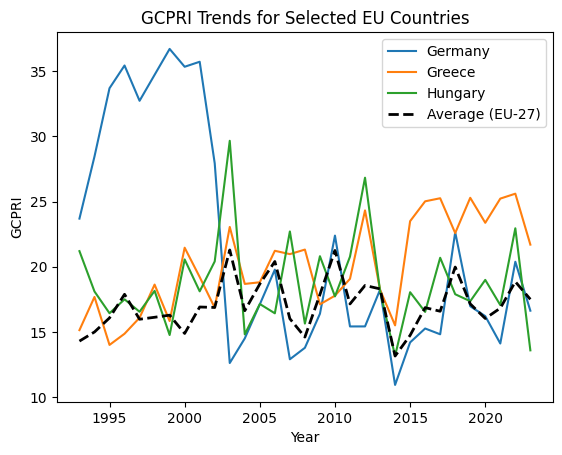

In [5]:
fig, ax = plt.subplots()

for country in df_filtered['Country'].unique()[9:12]:
    df_filtered[df_filtered['Country'] == country][['Year', 'GCPRI']].plot(x='Year', y='GCPRI', kind='line', ax=ax, label=country)

df_filtered.groupby('Year')['GCPRI'].mean().plot(x='Year', y='GCPRI', kind='line', linestyle='--', ax=ax, label='Average (EU-27)', color='black', linewidth=2)

ax.legend()
ax.set_ylabel('GCPRI')
ax.set_title('GCPRI Trends for Selected EU Countries')

Text(0.5, 1.0, 'EED and ERD Trends for Germany')

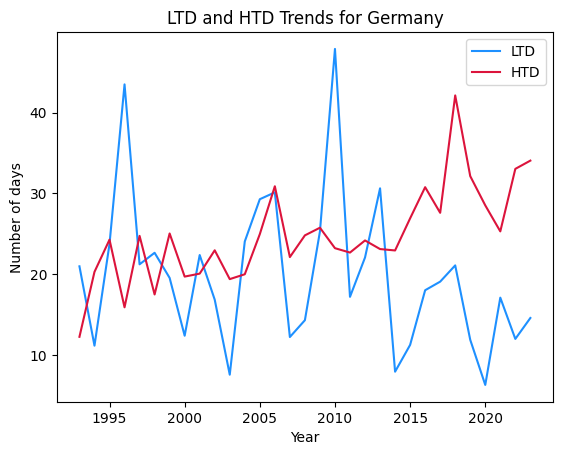

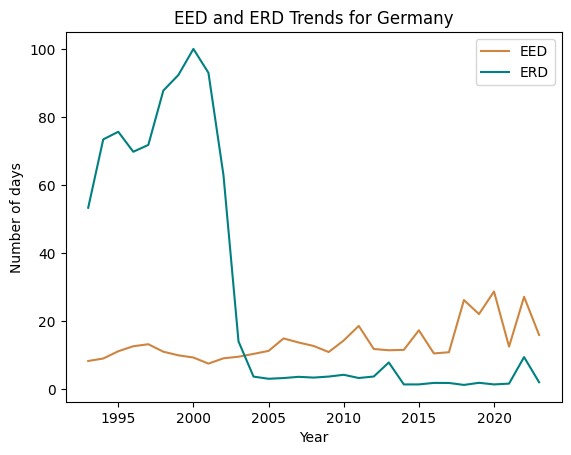

In [6]:
df_germany = df_filtered[df_filtered['Country'] == 'Germany']
fig, ax = plt.subplots()

df_germany.plot(x='Year', y='LTD', kind='line', ax=ax, label='LTD', color='dodgerblue')
df_germany.plot(x='Year', y='HTD', kind='line', ax=ax, label='HTD', color='crimson')

ax.set_ylabel('Number of days')
ax.set_title('LTD and HTD Trends for Germany')

fig, ax = plt.subplots()

df_germany.plot(x='Year', y='EED', kind='line', ax=ax, label='EED', color='peru')
df_germany.plot(x='Year', y='ERD', kind='line', ax=ax, label='ERD', color='teal')

ax.set_ylabel('Number of days')
ax.set_title('EED and ERD Trends for Germany')